# Chapter 17 — Trigram Models: Using Two Previous Tokens

A bigram model predicts from one previous token.

This chapter extends the same counting idea to a **trigram model**, which predicts from two previous tokens.

By the end of this chapter, you should be able to:

- distinguish bigram and trigram contexts;
- build sliding two-token contexts from token IDs;
- store counts in `context_to_target_counts` using tuple keys;
- decode context tuples for inspection;
- convert trigram target counts into probabilities;
- generate with trigram, bigram, and unigram backoff;
- measure context growth and sparsity; and
- explain why longer counted context requires much more data.

This chapter extends count-based language modeling without using neural networks.


## What “Trigram” Means

A **trigram** is a sequence of three adjacent tokens.

During next-token prediction, the first two tokens form the context and the third token is the target.

For the characters `"the"`, the context is `"th"` and the target is `"e"`.

The conditional distribution therefore has the form $P(\text{next token}\mid\text{previous two tokens})$.


## Why Two Tokens Can Help

A bigram model predicting after `"h"` combines every training occurrence ending in `"h"`.

A trigram model predicting after `"th"` uses a more specific local pattern.

That extra specificity can improve prediction, but it also splits the available observations among many more contexts.


## Reuse the Prepared Fixture

The same small fixture keeps the new context structure directly inspectable.


In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print(repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Build Stable Character IDs

Trigram contexts and targets will be stored as integer token IDs.


In [2]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    prepared_text
)
vocabulary_size = len(character_vocabulary)

print("Vocabulary size:", vocabulary_size)
for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>3}: {character!r}")

Vocabulary size: 22
  0: '\n'
  1: ' '
  2: '!'
  3: '.'
  4: 'T'
  5: 'a'
  6: 'b'
  7: 'c'
  8: 'd'
  9: 'e'
 10: 'g'
 11: 'h'
 12: 'i'
 13: 'k'
 14: 'l'
 15: 'n'
 16: 'o'
 17: 'r'
 18: 's'
 19: 't'
 20: 'w'
 21: 'y'


## Encode and Decode the Text

The exact round trip checks the numerical sequence before context windows are built.


In [3]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    token_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        token_ids.append(character_to_id[character])
    return token_ids


def decode_character_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []
    for position, token_id in enumerate(token_ids):
        if token_id not in id_to_character:
            raise ValueError(f"Unknown token ID {token_id} at position {position}.")
        characters.append(id_to_character[token_id])
    return "".join(characters)


token_ids = encode_characters(prepared_text, character_to_id)
decoded_text = decode_character_ids(token_ids, id_to_character)

assert decoded_text == prepared_text
print("Token count:", len(token_ids))
print("First 80 token IDs:", token_ids[:80])

Token count: 106
First 80 token IDs: [4, 11, 9, 1, 8, 16, 10, 1, 17, 5, 15, 1, 5, 7, 17, 16, 18, 18, 1, 19, 11, 9, 1, 21, 5, 17, 8, 3, 0, 4, 11, 9, 1, 7, 5, 19, 1, 18, 5, 19, 1, 15, 9, 5, 17, 1, 19, 11, 9, 1, 20, 12, 15, 8, 16, 20, 3, 0, 0, 4, 11, 9, 1, 8, 16, 10, 1, 14, 16, 16, 13, 9, 8, 1, 5, 19, 1, 19, 11, 9]


## Slide a Two-Token Context Window

At start position $i$, positions $i$ and $i+1$ form the context and position $i+2$ supplies the target.

Moving the start by one creates the next overlapping trigram observation.


In [4]:
def print_trigram_windows(text: str, number_of_windows: int) -> None:
    if number_of_windows < 0:
        raise ValueError("number_of_windows cannot be negative.")

    window_count = min(number_of_windows, max(0, len(text) - 2))
    for start_position in range(window_count):
        context_text = text[start_position : start_position + 2]
        target_character = text[start_position + 2]
        print(
            f"window {start_position:>2}: context {context_text!r:>6} "
            f"at [{start_position}, {start_position + 1}] → "
            f"target {target_character!r} at {start_position + 2}"
        )


print_trigram_windows(prepared_text, number_of_windows=12)

window  0: context   'Th' at [0, 1] → target 'e' at 2
window  1: context   'he' at [1, 2] → target ' ' at 3
window  2: context   'e ' at [2, 3] → target 'd' at 4
window  3: context   ' d' at [3, 4] → target 'o' at 5
window  4: context   'do' at [4, 5] → target 'g' at 6
window  5: context   'og' at [5, 6] → target ' ' at 7
window  6: context   'g ' at [6, 7] → target 'r' at 8
window  7: context   ' r' at [7, 8] → target 'a' at 9
window  8: context   'ra' at [8, 9] → target 'n' at 10
window  9: context   'an' at [9, 10] → target ' ' at 11
window 10: context   'n ' at [10, 11] → target 'a' at 12
window 11: context   ' a' at [11, 12] → target 'c' at 13


## Inspect One Context Tuple

A tuple is hashable, so two token IDs in a tuple can serve as a dictionary key while a list cannot.


In [5]:
tiny_text = "the"
tiny_vocabulary, tiny_character_to_id, tiny_id_to_character = build_character_mappings(
    tiny_text
)
tiny_token_ids = encode_characters(tiny_text, tiny_character_to_id)
tiny_context = (tiny_token_ids[0], tiny_token_ids[1])
tiny_target_id = tiny_token_ids[2]

print("Token IDs:", tiny_token_ids)
print("Context tuple:", tiny_context)
print(
    "Decoded context:", decode_character_ids(list(tiny_context), tiny_id_to_character)
)
print("Target ID:", tiny_target_id)
print("Decoded target:", decode_character_ids([tiny_target_id], tiny_id_to_character))

Token IDs: [2, 1, 0]
Context tuple: (2, 1)
Decoded context: th
Target ID: 0
Decoded target: e


## Count Targets After Every Context

The central data structure maps each two-token tuple to a `Counter` of target token IDs.

Its name, `context_to_target_counts`, makes that direction explicit.


In [6]:
from collections import Counter  # noqa: I001


Context = tuple[int, int]


def count_trigram_targets(
    token_ids: list[int],
) -> dict[Context, Counter[int]]:
    if len(token_ids) < 3:
        raise ValueError("token_ids must contain at least three IDs.")

    context_to_target_counts: dict[Context, Counter[int]] = {}
    for first_id, second_id, target_id in zip(
        token_ids[:-2],
        token_ids[1:-1],
        token_ids[2:],
        strict=True,
    ):
        context = (first_id, second_id)
        if context not in context_to_target_counts:
            context_to_target_counts[context] = Counter()
        context_to_target_counts[context][target_id] += 1
    return context_to_target_counts


context_to_target_counts = count_trigram_targets(token_ids)

print("Observed two-token contexts:", len(context_to_target_counts))
for context_number, (context, target_counts) in enumerate(
    context_to_target_counts.items()
):
    if context_number == 10:
        break
    print(context, "→", dict(target_counts))

Observed two-token contexts: 56
(4, 11) → {9: 4}
(11, 9) → {1: 7}
(9, 1) → {8: 2, 21: 1, 7: 3, 20: 1}
(1, 8) → {16: 2}
(8, 16) → {10: 2, 20: 1}
(16, 10) → {1: 2}
(10, 1) → {17: 1, 14: 1}
(1, 17) → {5: 1}
(17, 5) → {15: 1}
(5, 15) → {1: 1}


The raw ID tuples are compact for computation but inconvenient for a reader.

The next helper converts them back into two-character strings.


In [7]:
def decode_context(
    context: Context,
    id_to_character: dict[int, str],
) -> str:
    return decode_character_ids(list(context), id_to_character)


print("First ten decoded entries:")
for context_number, (context, target_counts) in enumerate(
    context_to_target_counts.items()
):
    if context_number == 10:
        break
    readable_targets = {
        id_to_character[target_id]: count for target_id, count in target_counts.items()
    }
    print(repr(decode_context(context, id_to_character)), "→", readable_targets)

First ten decoded entries:
'Th' → {'e': 4}
'he' → {' ': 7}
'e ' → {'d': 2, 'y': 1, 'c': 3, 'w': 1}
' d' → {'o': 2}
'do' → {'g': 2, 'w': 1}
'og' → {' ': 2}
'g ' → {'r': 1, 'l': 1}
' r' → {'a': 1}
'ra' → {'n': 1}
'an' → {' ': 1}


## Inspect Targets for Readable Contexts

The helper accepts exactly two characters, encodes them, and reports the observed targets.


In [8]:
def context_from_text(
    context_text: str,
    character_to_id: dict[str, int],
) -> Context:
    if len(context_text) != 2:
        raise ValueError("context_text must contain exactly two characters.")
    context_ids = encode_characters(context_text, character_to_id)
    return context_ids[0], context_ids[1]


def print_target_counts(
    context_text: str,
    context_to_target_counts: dict[Context, Counter[int]],
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
) -> None:
    context = context_from_text(context_text, character_to_id)
    print("Context:", repr(context_text))
    target_counts = context_to_target_counts.get(context)
    if target_counts is None:
        print("  no observed targets")
        return
    for target_id, count in target_counts.most_common():
        print(f"  next {id_to_character[target_id]!r:>6}: {count}")


for context_text in ["Th", "th", "he", "e ", " c", "ca", "at", "t!", ".\n"]:
    print_target_counts(
        context_text,
        context_to_target_counts,
        character_to_id,
        id_to_character,
    )
    print()

Context: 'Th'
  next    'e': 4

Context: 'th'
  next    'e': 3

Context: 'he'
  next    ' ': 7

Context: 'e '
  next    'c': 3
  next    'd': 2
  next    'y': 1
  next    'w': 1

Context: ' c'
  next    'a': 3

Context: 'ca'
  next    't': 3

Context: 'at'
  next    ' ': 4
  next    '!': 1

Context: 't!'
  next   '\n': 1

Context: '.\n'
  next    'T': 1
  next   '\n': 1



## Verify the Number of Trigram Observations

A sequence of length $N$ contains $N-2$ windows of three adjacent tokens.


In [9]:
def total_target_count(
    context_to_target_counts: dict[Context, Counter[int]],
) -> int:
    return sum(
        sum(target_counts.values())
        for target_counts in context_to_target_counts.values()
    )


total_trigram_count = total_target_count(context_to_target_counts)
expected_trigram_count = len(token_ids) - 2

print("Counted trigram observations:", total_trigram_count)
print("Expected observations:", expected_trigram_count)
assert total_trigram_count == expected_trigram_count

Counted trigram observations: 104
Expected observations: 104


## Print Context-Target Training Examples

Decoding the examples makes off-by-one mistakes visible before probabilities are built.


In [10]:
def print_trigram_examples(
    token_ids: list[int],
    id_to_character: dict[int, str],
    max_examples: int,
) -> None:
    if max_examples < 0:
        raise ValueError("max_examples cannot be negative.")

    for start_position in range(min(max_examples, len(token_ids) - 2)):
        context_ids = token_ids[start_position : start_position + 2]
        target_id = token_ids[start_position + 2]
        print(
            f"example {start_position:>2}: IDs {context_ids} "
            f"context {decode_character_ids(context_ids, id_to_character)!r} → "
            f"ID {target_id} target {id_to_character[target_id]!r}"
        )


print_trigram_examples(token_ids, id_to_character, max_examples=12)

example  0: IDs [4, 11] context 'Th' → ID 9 target 'e'
example  1: IDs [11, 9] context 'he' → ID 1 target ' '
example  2: IDs [9, 1] context 'e ' → ID 8 target 'd'
example  3: IDs [1, 8] context ' d' → ID 16 target 'o'
example  4: IDs [8, 16] context 'do' → ID 10 target 'g'
example  5: IDs [16, 10] context 'og' → ID 1 target ' '
example  6: IDs [10, 1] context 'g ' → ID 17 target 'r'
example  7: IDs [1, 17] context ' r' → ID 5 target 'a'
example  8: IDs [17, 5] context 'ra' → ID 15 target 'n'
example  9: IDs [5, 15] context 'an' → ID 1 target ' '
example 10: IDs [15, 1] context 'n ' → ID 5 target 'a'
example 11: IDs [1, 5] context ' a' → ID 7 target 'c'


## Compare Bigram and Trigram Contexts

For the target `"e"` at position two, the bigram model sees only `"h"`, while the trigram model sees `"Th"`.


In [11]:
target_position = 2
bigram_context = decode_character_ids(
    [token_ids[target_position - 1]],
    id_to_character,
)
trigram_context = decode_character_ids(
    token_ids[target_position - 2 : target_position],
    id_to_character,
)
target_character = id_to_character[token_ids[target_position]]

print("Bigram context:", repr(bigram_context))
print("Trigram context:", repr(trigram_context))
print("Target:", repr(target_character))

Bigram context: 'h'
Trigram context: 'Th'
Target: 'e'


## Convert Target Counts Into Probabilities

For each observed context, divide every target count by the total count under that same context.


In [12]:
def assert_valid_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")
    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities cannot be negative.")
    if abs(sum(probabilities) - 1.0) > 1e-12:
        raise ValueError("Probabilities must sum to 1.")


def target_counts_to_probabilities(
    target_counts: Counter[int],
    vocabulary_size: int,
) -> list[float]:
    total_count = sum(target_counts.values())
    if total_count <= 0:
        raise ValueError("target_counts must contain observations.")
    probabilities = [
        target_counts[target_id] / total_count for target_id in range(vocabulary_size)
    ]
    assert_valid_probability_distribution(probabilities)
    return probabilities


def build_context_probabilities(
    context_to_target_counts: dict[Context, Counter[int]],
    vocabulary_size: int,
) -> dict[Context, list[float]]:
    return {
        context: target_counts_to_probabilities(target_counts, vocabulary_size)
        for context, target_counts in context_to_target_counts.items()
    }


context_to_target_probabilities = build_context_probabilities(
    context_to_target_counts,
    vocabulary_size,
)

for row in context_to_target_probabilities.values():
    assert_valid_probability_distribution(row)
print("Valid trigram probability rows:", len(context_to_target_probabilities))

Valid trigram probability rows: 56


## Inspect the Distribution After `"th"`

This row estimates $P(\text{next character}\mid\text{"th"})$ from the fixture.


In [13]:
context_text = "th"
context = context_from_text(context_text, character_to_id)
probabilities_after_th = context_to_target_probabilities[context]

print("Context:", repr(context_text))
for target_id, probability in enumerate(probabilities_after_th):
    if probability > 0:
        print(f"  next {id_to_character[target_id]!r:>6}: {probability:.6f}")

Context: 'th'
  next    'e': 1.000000


## Plot One Trigram Distribution

The plot shows only the next-token probabilities under the specific context `"th"`.


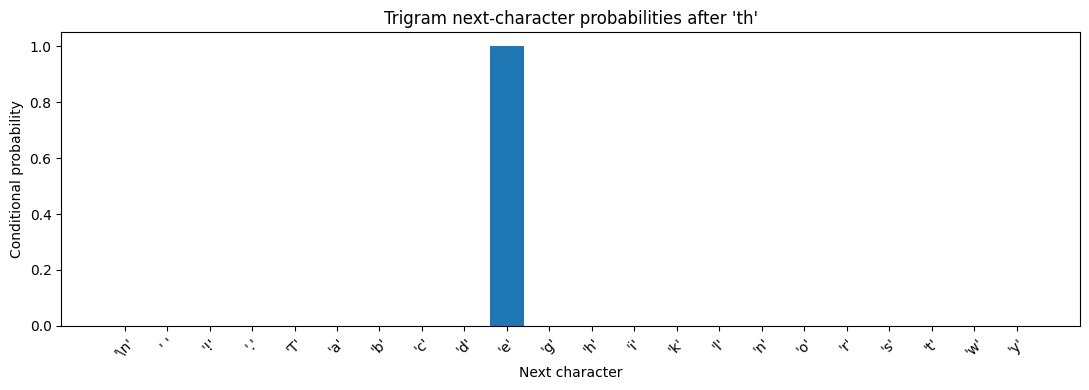

In [14]:
import matplotlib.pyplot as plt  # noqa: I001


labels = [repr(character) for character in character_vocabulary]

plt.figure(figsize=(11, 4))
plt.bar(labels, probabilities_after_th)
plt.xlabel("Next character")
plt.ylabel("Conditional probability")
plt.title("Trigram next-character probabilities after 'th'")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Build Bigram and Unigram Backoff Rows

An unseen two-token context has no trigram row.

We will **back off** first to the final one-token context and then to overall unigram probabilities.

Backoff selects a less specific fitted distribution, while smoothing changes probability values within a distribution.


In [15]:
def count_bigram_targets(token_ids: list[int]) -> dict[int, Counter[int]]:
    if len(token_ids) < 2:
        raise ValueError("token_ids must contain at least two IDs.")

    previous_to_target_counts: dict[int, Counter[int]] = {}
    for previous_id, target_id in zip(token_ids[:-1], token_ids[1:], strict=True):
        if previous_id not in previous_to_target_counts:
            previous_to_target_counts[previous_id] = Counter()
        previous_to_target_counts[previous_id][target_id] += 1
    return previous_to_target_counts


bigram_target_counts = count_bigram_targets(token_ids)
bigram_probabilities = {
    previous_id: target_counts_to_probabilities(target_counts, vocabulary_size)
    for previous_id, target_counts in bigram_target_counts.items()
}


def count_token_ids(token_ids: list[int], vocabulary_size: int) -> list[int]:
    counts = [0 for _ in range(vocabulary_size)]
    for token_id in token_ids:
        counts[token_id] += 1
    return counts


unigram_counts = count_token_ids(token_ids, vocabulary_size)
unigram_total = sum(unigram_counts)
unigram_probabilities = [count / unigram_total for count in unigram_counts]
assert_valid_probability_distribution(unigram_probabilities)

## Find an Unseen Context Made of Known Characters

The search demonstrates that known individual tokens can still form an unseen pair.


In [16]:
def find_unseen_context(
    vocabulary: list[str],
    character_to_id: dict[str, int],
    observed_contexts: dict[Context, Counter[int]],
) -> str:
    for first_character in vocabulary:
        for second_character in vocabulary:
            context_text = first_character + second_character
            context = context_from_text(context_text, character_to_id)
            if context not in observed_contexts:
                return context_text
    raise ValueError("Every possible two-token context was observed.")


unseen_context_text = find_unseen_context(
    character_vocabulary,
    character_to_id,
    context_to_target_counts,
)

print("Unseen context using known characters:", repr(unseen_context_text))
print_target_counts(
    unseen_context_text,
    context_to_target_counts,
    character_to_id,
    id_to_character,
)

Unseen context using known characters: '\n '
Context: '\n '
  no observed targets


## Package the Backoff Trigram Model

The prediction method returns both a probability row and the level that supplied it so backoff remains visible.


In [17]:
class BackoffTrigramModel:
    def __init__(
        self,
        trigram_probabilities: dict[Context, list[float]],
        bigram_probabilities: dict[int, list[float]],
        unigram_probabilities: list[float],
    ):
        assert_valid_probability_distribution(unigram_probabilities)
        for row in trigram_probabilities.values():
            assert_valid_probability_distribution(row)
        for row in bigram_probabilities.values():
            assert_valid_probability_distribution(row)
        self.trigram_probabilities = trigram_probabilities
        self.bigram_probabilities = bigram_probabilities
        self.unigram_probabilities = unigram_probabilities

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> tuple[list[float], str]:
        if len(input_token_ids) >= 2:
            context = input_token_ids[-2], input_token_ids[-1]
            if context in self.trigram_probabilities:
                return self.trigram_probabilities[context], "trigram"

        if input_token_ids:
            previous_id = input_token_ids[-1]
            if previous_id in self.bigram_probabilities:
                return self.bigram_probabilities[previous_id], "bigram"

        return self.unigram_probabilities, "unigram"


trigram_model = BackoffTrigramModel(
    context_to_target_probabilities,
    bigram_probabilities,
    unigram_probabilities,
)

## Test Observed and Unseen Contexts

Observed pairs use trigram rows, while an unseen pair reports a bigram backoff.


In [18]:
def most_likely_token_id(probabilities: list[float]) -> int:
    assert_valid_probability_distribution(probabilities)
    return max(range(len(probabilities)), key=probabilities.__getitem__)


for context_text in ["th", "Th", "ca", unseen_context_text]:
    context_ids = encode_characters(context_text, character_to_id)
    probabilities, level = trigram_model.predict_next_token_probabilities(context_ids)
    best_id = most_likely_token_id(probabilities)
    print(
        f"context {context_text!r:>6}: used {level:<7}; "
        f"best next {id_to_character[best_id]!r} at {probabilities[best_id]:.6f}"
    )

context   'th': used trigram; best next 'e' at 1.000000
context   'Th': used trigram; best next 'e' at 1.000000
context   'ca': used trigram; best next 't' at 1.000000
context  '\n ': used bigram ; best next 'c' at 0.166667


## Measure Context Growth

With vocabulary size $V$, a bigram model has at most $V$ one-token contexts and a trigram model has at most $V^2$ two-token contexts.


In [19]:
possible_bigram_contexts = vocabulary_size
possible_trigram_contexts = vocabulary_size**2
observed_trigram_contexts = len(context_to_target_counts)

print("Possible bigram contexts:", possible_bigram_contexts)
print("Possible trigram contexts:", possible_trigram_contexts)
print("Observed trigram contexts:", observed_trigram_contexts)
print("Observed fraction:", observed_trigram_contexts / possible_trigram_contexts)

Possible bigram contexts: 22
Possible trigram contexts: 484
Observed trigram contexts: 56
Observed fraction: 0.11570247933884298


## Visualize Possible and Observed Context Counts

The plot makes the sparse coverage of the two-token context space visible.


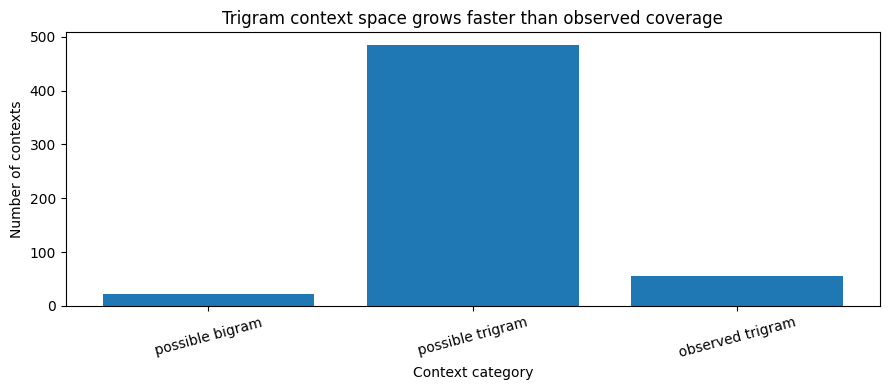

In [20]:
context_categories = [
    "possible bigram",
    "possible trigram",
    "observed trigram",
]
context_counts = [
    possible_bigram_contexts,
    possible_trigram_contexts,
    observed_trigram_contexts,
]

plt.figure(figsize=(9, 4))
plt.bar(context_categories, context_counts)
plt.xlabel("Context category")
plt.ylabel("Number of contexts")
plt.title("Trigram context space grows faster than observed coverage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Measure Rare Contexts

A context observed once can produce an unsmoothed probability-one target based on only one example.


In [21]:
context_observation_counts = {
    context: sum(target_counts.values())
    for context, target_counts in context_to_target_counts.items()
}
one_observation_contexts = [
    context
    for context, observation_count in context_observation_counts.items()
    if observation_count == 1
]

print("Contexts observed once:", len(one_observation_contexts))
print("First twenty:")
for context in one_observation_contexts[:20]:
    readable_targets = {
        id_to_character[target_id]: count
        for target_id, count in context_to_target_counts[context].items()
    }
    print(f"  {decode_context(context, id_to_character)!r:>6} → {readable_targets}")

Contexts observed once: 31
First twenty:
    ' r' → {'a': 1}
    'ra' → {'n': 1}
    'an' → {' ': 1}
    'n ' → {'a': 1}
    'cr' → {'o': 1}
    'ro' → {'s': 1}
    'os' → {'s': 1}
    'ss' → {' ': 1}
    's ' → {'t': 1}
    ' y' → {'a': 1}
    'ya' → {'r': 1}
    'rd' → {'.': 1}
    'd.' → {'\n': 1}
    ' s' → {'a': 1}
    'sa' → {'t': 1}
    ' n' → {'e': 1}
    'ne' → {'a': 1}
    'ea' → {'r': 1}
    'r ' → {'t': 1}
    ' w' → {'i': 1}


## Plot Context Observation Frequencies

The chart counts how many contexts received one observation, two observations, and so on.


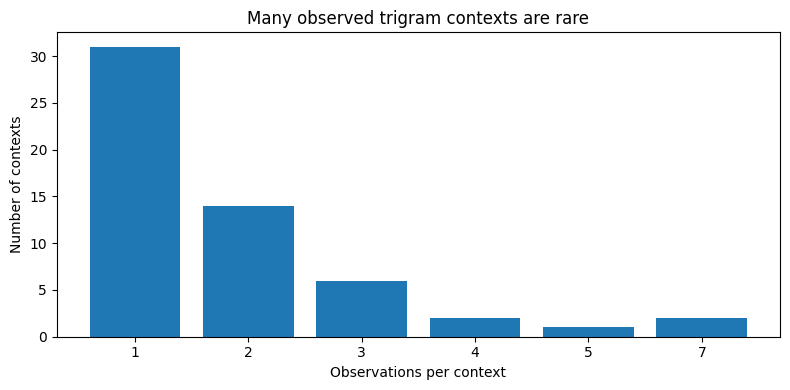

In [22]:
observation_frequency = Counter(context_observation_counts.values())
x_values = sorted(observation_frequency)
y_values = [observation_frequency[value] for value in x_values]

plt.figure(figsize=(8, 4))
plt.bar([str(value) for value in x_values], y_values)
plt.xlabel("Observations per context")
plt.ylabel("Number of contexts")
plt.title("Many observed trigram contexts are rare")
plt.tight_layout()
plt.show()

## Generate With Visible Backoff

Generation uses the final two IDs when their context was observed and backs off when it was not.


In [23]:
import random  # noqa: I001


RANDOM_SEED = 17


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    assert_valid_probability_distribution(probabilities)
    return random_generator.choices(
        range(len(probabilities)),
        weights=probabilities,
        k=1,
    )[0]


def generate_trigram_text(
    model: BackoffTrigramModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> tuple[str, Counter[str]]:
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    random_generator = random.Random(random_seed)
    generated_text = prompt
    level_counts: Counter[str] = Counter()
    for _ in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities, level = model.predict_next_token_probabilities(input_ids)
        level_counts[level] += 1
        next_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_id]
    return generated_text, level_counts


generated_text, generation_level_counts = generate_trigram_text(
    trigram_model,
    prompt="Th",
    number_of_new_characters=160,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)

print(generated_text)
print()
print(repr(generated_text))
print("Prediction levels used:", dict(generation_level_counts))

The yard.

The cat the cat!
The cat!
The cat the cat neard.

The yar the dog ran across the windog looked back.
The dog ran across the cat near the dog looked at 

'The yard.\n\nThe cat the cat!\nThe cat!\nThe cat the cat neard.\n\nThe yar the dog ran across the windog looked back.\nThe dog ran across the cat near the dog looked at '
Prediction levels used: {'trigram': 159, 'bigram': 1}


The generated sample can preserve longer local fragments than a bigram model, but rare-context certainty and backoff remain visible limitations.


## Trace the Sliding Context

The short trace shows the final two characters, the selected model level, and the sampled target at every step.


In [24]:
def trace_trigram_generation(
    model: BackoffTrigramModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    random_generator = random.Random(random_seed)
    generated_text = prompt

    for step in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities, level = model.predict_next_token_probabilities(input_ids)
        next_id = sample_token_id(probabilities, random_generator)
        context_text = generated_text[-2:]
        print(
            f"step {step + 1:>2}: context {context_text!r:>6}, "
            f"level {level:<7}, sampled {id_to_character[next_id]!r} "
            f"at {probabilities[next_id]:.6f}"
        )
        generated_text += id_to_character[next_id]
    return generated_text


traced_text = trace_trigram_generation(
    trigram_model,
    prompt="Th",
    number_of_new_characters=12,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)
print("Final traced text:", repr(traced_text))

step  1: context   'Th', level trigram, sampled 'e' at 1.000000
step  2: context   'he', level trigram, sampled ' ' at 1.000000
step  3: context   'e ', level trigram, sampled 'y' at 0.142857
step  4: context   ' y', level trigram, sampled 'a' at 1.000000
step  5: context   'ya', level trigram, sampled 'r' at 1.000000
step  6: context   'ar', level trigram, sampled 'd' at 0.500000
step  7: context   'rd', level trigram, sampled '.' at 1.000000
step  8: context   'd.', level trigram, sampled '\n' at 1.000000
step  9: context  '.\n', level trigram, sampled '\n' at 0.500000
step 10: context '\n\n', level trigram, sampled 'T' at 1.000000
step 11: context  '\nT', level trigram, sampled 'h' at 1.000000
step 12: context   'Th', level trigram, sampled 'e' at 1.000000
Final traced text: 'The yard.\n\nThe'


## See Exponential Context Growth

Increasing counted context length from one to four tokens produces $V$, $V^2$, $V^3$, and $V^4$ possible contexts.


Context length | Possible contexts
----------------------------------
             1 |                22
             2 |               484
             3 |             10648
             4 |            234256


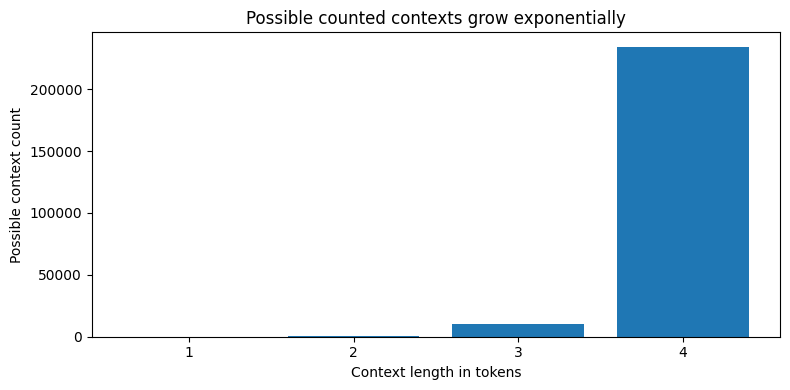

In [25]:
context_lengths = [1, 2, 3, 4]
possible_context_counts = [
    vocabulary_size**context_length for context_length in context_lengths
]

print("Context length | Possible contexts")
print("-" * 34)
for context_length, possible_count in zip(
    context_lengths,
    possible_context_counts,
    strict=True,
):
    print(f"{context_length:>14} | {possible_count:>17}")

plt.figure(figsize=(8, 4))
plt.bar([str(length) for length in context_lengths], possible_context_counts)
plt.xlabel("Context length in tokens")
plt.ylabel("Possible context count")
plt.title("Possible counted contexts grow exponentially")
plt.tight_layout()
plt.show()

More context can make predictions more specific, but raw n-gram counting cannot share evidence efficiently across all of these possible contexts.


## Complete Trigram Pipeline

The final cell rebuilds all three probability levels, checks the observation count, and generates a deterministic sample.


In [26]:
final_vocabulary, final_character_to_id, final_id_to_character = (
    build_character_mappings(prepared_text)
)
final_token_ids = encode_characters(prepared_text, final_character_to_id)
final_trigram_counts = count_trigram_targets(final_token_ids)
final_trigram_probabilities = build_context_probabilities(
    final_trigram_counts,
    len(final_vocabulary),
)
final_bigram_counts = count_bigram_targets(final_token_ids)
final_bigram_probabilities = {
    previous_id: target_counts_to_probabilities(
        target_counts,
        len(final_vocabulary),
    )
    for previous_id, target_counts in final_bigram_counts.items()
}
final_unigram_counts = count_token_ids(final_token_ids, len(final_vocabulary))
final_unigram_total = sum(final_unigram_counts)
final_unigram_probabilities = [
    count / final_unigram_total for count in final_unigram_counts
]
final_model = BackoffTrigramModel(
    final_trigram_probabilities,
    final_bigram_probabilities,
    final_unigram_probabilities,
)
final_generated_text, final_level_counts = generate_trigram_text(
    final_model,
    prompt="Th",
    number_of_new_characters=80,
    character_to_id=final_character_to_id,
    id_to_character=final_id_to_character,
    random_seed=RANDOM_SEED,
)

assert total_target_count(final_trigram_counts) == len(final_token_ids) - 2
assert set(final_generated_text).issubset(set(final_vocabulary))
print("Vocabulary size:", len(final_vocabulary))
print("Possible contexts:", len(final_vocabulary) ** 2)
print("Observed contexts:", len(final_trigram_counts))
print("Prediction levels:", dict(final_level_counts))
print("Generated text:", repr(final_generated_text))

Vocabulary size: 22
Possible contexts: 484
Observed contexts: 56
Prediction levels: {'trigram': 80}
Generated text: 'The yard.\n\nThe cat the cat!\nThe cat!\nThe cat the cat neard.\n\nThe yar the dog ran a'


## Common Mistakes

- A trigram contains three tokens, but its prediction context contains the first two.

- Store the two context IDs in an ordered tuple rather than an unordered set.

- A sequence of length $N$ has $N-2$ trigram observations.

- Decode ID tuples when inspecting them so hidden whitespace remains visible.

- Do not treat probability one from one observation as strong evidence.

- Keep backoff distinct from smoothing.

- Remember that the model uses only the final two prompt tokens.


## Takeaways

A trigram model maps an ordered tuple of two previous token IDs to counts and probabilities for one target token.

Its `context_to_target_counts` structure provides more specific local predictions than a bigram model.

That specificity creates up to $V^2$ contexts, many of which are rare or unseen in a small corpus.

Backoff keeps generation defined by using a less specific context when a trigram row is unavailable, but it does not remove the underlying sparsity.

The next chapter introduces log probabilities so products of many small token probabilities can be represented as sums during model evaluation.
